# Unsupervised Learning Task: PCA and Clustering on US Arrests Data

This notebook performs an in-depth PCA and clustering analysis on the **UsArrests.csv** dataset.

## Load Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

plt.show()

# Load dataset (ensure UsArrests.csv is in the same folder)
df = pd.read_csv('UsArrests.csv', index_col=0)
df.head()

,Murder,Assault,UrbanPop,Rape
City,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


##  Data Exploration and Preprocessing
We examine summary statistics, data types, and missing values. Since PCA is scale-sensitive, standardisation is required.

In [2]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB


,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


### Preprocessing Motivation
- Variables are measured on different scales.
- Standardisation ensures each variable contributes equally to PCA.

In [3]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, index=df.index, columns=df.columns)
scaled_df.head()

,Murder,Assault,UrbanPop,Rape
City,,,,
Alabama,1.255179,0.790787,-0.526195,-0.003451
Alaska,0.513019,1.118060,-1.224067,2.509424
Arizona,0.072361,1.493817,1.009122,1.053466
Arkansas,0.234708,0.233212,-1.084492,-0.186794
California,0.281093,1.275635,1.776781,2.088814


##  Correlation Analysis
Correlation analysis helps identify relationships between variables and potential redundancy.

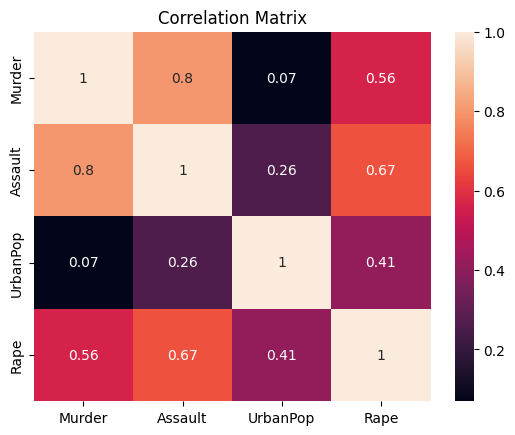

In [4]:
corr = df.corr()
corr

plt.figure()
sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

**Interpretation:**
- Strong positive correlations indicate variables that may load similarly in PCA.

##  Principal Component Analysis (PCA)

In [5]:
pca = PCA()
pca_data = pca.fit_transform(scaled_df)

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

### Explained Variance

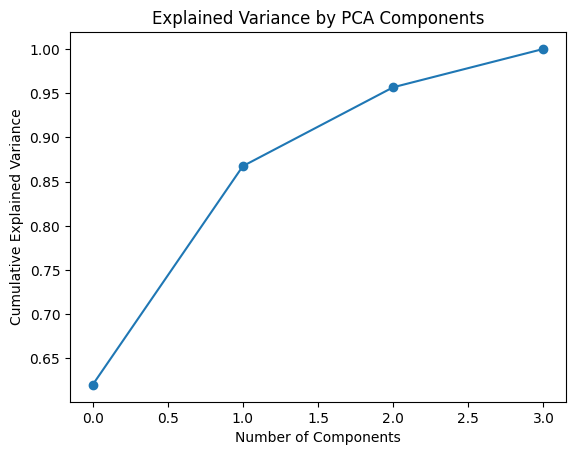

In [6]:
plt.figure()
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.show()

##  Biplot of First Two Principal Components

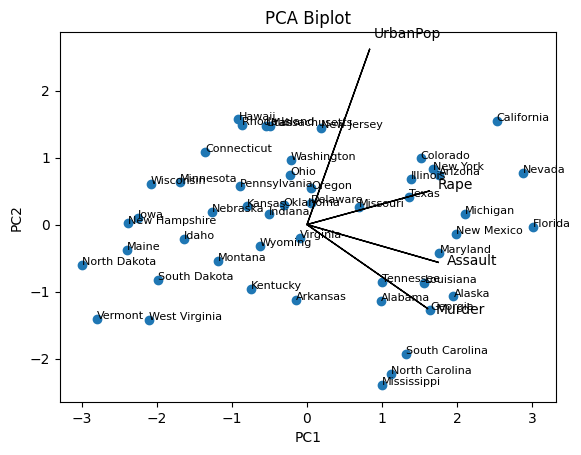

In [7]:
pca_2 = PCA(n_components=2)
pca_scores = pca_2.fit_transform(scaled_df)

plt.figure()
plt.scatter(pca_scores[:,0], pca_scores[:,1])
for i, state in enumerate(df.index):
    plt.text(pca_scores[i,0], pca_scores[i,1], state, fontsize=8)

for i, feature in enumerate(df.columns):
    plt.arrow(0, 0, pca_2.components_[0,i]*3, pca_2.components_[1,i]*3)
    plt.text(pca_2.components_[0,i]*3.2, pca_2.components_[1,i]*3.2, feature)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot')
plt.show()

**Biplot Interpretation:**
- Points close together represent states with similar arrest patterns.
- Arrows indicate variable contributions to each principal component.

## Selecting Number of Principal Components
We retain components explaining most of the variance (e.g., >80%). From the scree plot, the first two or three components are sufficient.

## Clustering Analysis

### K-Means Clustering

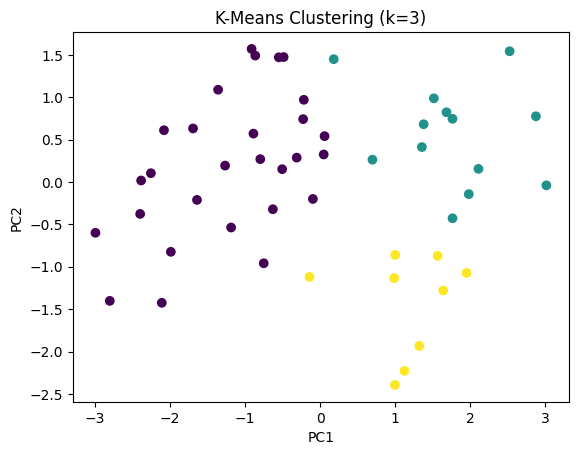

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_scores)

plt.figure()
plt.scatter(pca_scores[:,0], pca_scores[:,1], c=clusters)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering (k=3)')
plt.show()

### Hierarchical Clustering

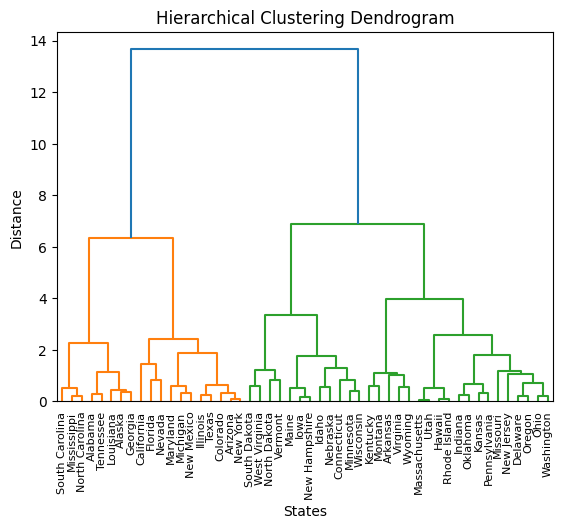

In [9]:
linked = linkage(pca_scores, method='ward')

plt.figure()
dendrogram(linked, labels=df.index)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('States')
plt.ylabel('Distance')
plt.show()

## Cluster Interpretation
- States within the same cluster share similar crime profiles.
- Both methods show consistent grouping of high- and low-crime states.
- Differences arise due to algorithm assumptions and distance metrics.